In [47]:
import pandas as pd
import ydata_profiling as yp
candy_old = pd.read_csv('/Users/A107809368/projects/playground/candy_case_study/data/candy-data.csv')

In [ ]:
report = yp.ProfileReport(candy)
report.to_file('/Users/A107809368/projects/playground/candy_case_study/reports/eda_report.html')

- The report is saved as an HTML file in the specified directory.
- data is pretty clean, no missing values, no major problems detected at first sight
- only issue at the beginning is that the last variable 'winpercent' has a different format then other percent variables (0-100 instead of 0-1)
- will need to convert that variable before modeling

In [52]:
candy['winpercent'] = candy['winpercent'].apply(lambda x: round(x / 100, 3))

In [35]:
candy.to_csv('/Users/A107809368/projects/playground/candy_case_study/data/candy-data-cleaned.csv', index=False)

In [32]:
import pandas as pd
candy = pd.read_csv('/Users/A107809368/projects/playground/candy_case_study/data/candy-data-cleaned.csv')
candy.sort_values(by='winpercent', ascending=False)

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent,mother_company
52,Reese's Peanut Butter cup,1,0,0,1,0,0,0,0,0,0.720,0.651,0.842,Hershey's
51,Reese's Miniatures,1,0,0,1,0,0,0,0,0,0.034,0.279,0.819,Zeta Espacial
79,Twix,1,0,1,0,0,1,0,1,0,0.546,0.906,0.816,"Mars, Inc."
28,Kit Kat,1,0,0,0,0,1,0,1,0,0.313,0.511,0.768,Hershey's
64,Snickers,1,0,1,1,1,0,0,1,0,0.546,0.651,0.767,Mondelez International
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26,Jawbusters,0,1,0,0,0,0,1,0,1,0.093,0.511,0.281,Ferrara Candy Company
72,Super Bubble,0,1,0,0,0,0,0,0,0,0.162,0.116,0.273,"Mars, Inc."
12,Chiclets,0,1,0,0,0,0,0,0,1,0.046,0.325,0.245,Mondelez International
7,Boston Baked Beans,0,0,0,1,0,0,0,0,1,0.313,0.511,0.234,Ferrara Candy Company


In [6]:
# create one long string from all the competitor names separated by comma
competitor_names = ', '.join(candy['competitorname'].tolist())

In [33]:
# standardize all numeric values
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_cols = ['sugarpercent']
candy[numeric_cols] = scaler.fit_transform(candy[numeric_cols])

In [34]:
candy

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent,mother_company
0,100 Grand,1,0,1,0,0,1,0,1,0,0.901261,0.860,0.670,Ferrero
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.445922,0.511,0.676,"Mars, Inc."
2,One dime,0,0,0,0,0,0,0,0,0,-1.663576,0.116,0.323,Unknown
3,One quarter,0,0,0,0,0,0,0,0,0,-1.663576,0.511,0.461,Unknown
4,Air Heads,0,1,0,0,0,0,0,0,0,1.520236,0.511,0.523,Perfetti Van Melle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,Twizzlers,0,1,0,0,0,0,0,0,0,-0.920093,0.116,0.455,Hershey's
81,Warheads,0,1,0,0,0,0,1,0,0,-1.371875,0.116,0.390,Impact Confections
82,Welch's Fruit Snacks,0,1,0,0,0,0,0,0,1,-0.589262,0.313,0.444,Welch Foods Inc.
83,Werther's Original Caramel,0,0,1,0,0,0,1,0,0,-1.041043,0.267,0.419,Storck


In [19]:
from utils import get_gpt_response
prompt = 'Determine mother companies of the following candy brands. Return only the mother company names. If unknown, return "Unknown".\n\n Separate the names by a semi-colon, so that it can be easily read out as separated values. Make sure you have the same number of mother company names as the candy brands. Candy brands:'
response = get_gpt_response(prompt + competitor_names)

In [20]:
companies = response.split(';')
print(len(companies)) #to check if the number of companies matches the number of candy brands

In [23]:
candy['mother_company'] = [company.strip() for company in companies]

In [25]:
candy[['competitorname', 'mother_company']]

,competitorname,mother_company
0,100 Grand,Ferrero
1,3 Musketeers,"Mars, Inc."
2,One dime,Unknown
3,One quarter,Unknown
4,Air Heads,Perfetti Van Melle
...,...,...
80,Twizzlers,Hershey's
81,Warheads,Impact Confections
82,Welch's Fruit Snacks,Welch Foods Inc.
83,Werther's Original Caramel,Storck


In [55]:
candy.mother_company.value_counts()

mother_company
Hershey's                  17
Mars, Inc.                 14
Ferrero                    13
Tootsie Roll Industries     8
Nestle                      5
Ferrara Candy Company       5
Mondelez International      4
Haribo                      4
Unknown                     4
Perfetti Van Melle          2
Spangler Candy Company      1
Just Born                   1
Zeta Espacial               1
Atkinson Candy Company      1
Sweetworks                  1
Smarties Candy Company      1
Impact Confections          1
Welch Foods Inc.            1
Storck                      1
Name: count, dtype: int64

In [37]:
candy.loc[candy['mother_company'] == 'Unknown', ['competitorname', 'mother_company']]
candy.loc[candy['competitorname'] == 'Starburst']['mother_company'] = 'Mars, Inc.'
candy.loc[candy['competitorname'] == 'Milky Way']['mother_company'] = 'Mars, Inc.'

candy = candy.replace("Hershey's.", "Hershey's")
candy = candy.replace("Hershey’s", "Hershey's")

/var/folders/3r/pv_sqnpd6bb8wr1nhrml1snw0000gq/T/ipykernel_96827/1589415653.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  candy.loc[candy['competitorname'] == 'Starburst']['mother_company'] = 'Mars, Inc.'


/var/folders/3r/pv_sqnpd6bb8wr1nhrml1snw0000gq/T/ipykernel_96827/3105872212.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  candy.loc[candy['competitorname'] == 'Milky Way']['mother_company'] = 'Mars, Inc.'


In [ ]:
test = candy.iloc[:,1:10].apply(lambda x: str(x), axis=1)

In [ ]:
import re
combinations = []
for row in test:
    code = re.sub(r'[^\d]', '', row)[:9]
    combinations.append(code)

In [ ]:
# count unique elements in the list
unique_combinations = set(combinations)
len(unique_combinations)

In [ ]:
# count number of occurrences of each unique element in the list
from collections import Counter
combination_counts = Counter(combinations)
combination_counts

In [ ]:
candy['combination'] = combinations
candy[candy['combination'] == '010000001'][['competitorname', 'winpercent']]
candy[candy['combination'] == '100100000'][['competitorname', 'winpercent']]

In [54]:
candy

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent,mother_company
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,0.670,Ferrero
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,0.676,"Mars, Inc."
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,0.323,Unknown
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,0.461,Unknown
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,0.523,Perfetti Van Melle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,Twizzlers,0,1,0,0,0,0,0,0,0,0.220,0.116,0.455,Hershey's
81,Warheads,0,1,0,0,0,0,1,0,0,0.093,0.116,0.390,Impact Confections
82,Welch's Fruit Snacks,0,1,0,0,0,0,0,0,1,0.313,0.313,0.444,Welch Foods Inc.
83,Werther's Original Caramel,0,0,1,0,0,0,1,0,0,0.186,0.267,0.419,Storck


In [69]:
dummies = pd.get_dummies(candy['mother_company'], drop_first=True, dtype=int)
candy = pd.concat([candy, dummies], axis=1)

In [70]:
# model winpercent by ols on all other features except for combination and competitorname
import statsmodels.api as sm
X = candy.drop(columns=['winpercent', 'competitorname', 'mother_company'])
y = candy['winpercent']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             winpercent   R-squared:                       0.664
Model:                            OLS   Adj. R-squared:                  0.486
Method:                 Least Squares   F-statistic:                     3.741
Date:                Mon, 03 Nov 2025   Prob (F-statistic):           1.27e-05
Time:                        22:12:00   Log-Likelihood:                 89.050
No. Observations:                  85   AIC:                            -118.1
Df Residuals:                      55   BIC:                            -44.82
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       0.4002      0.128      3.124      0.003       0.143       0.657
chocolate                   0.1965      0.047      4.138      0.000       0.101       0.292
fruity                      0.1214      0.044      2.784      0.007       0.034       0.209
caramel                     0.0287      0.047      0.610      0.544      -0.066       0.123
peanutyalmondy              0.1022      0.040      2.572      0.013       0.023       0.182
nougat                      0.0208      0.058      0.357      0.722      -0.096       0.137
crispedricewafer            0.0965      0.053      1.808      0.076      -0.010       0.203
hard                       -0.0354      0.042     -0.835      0.407      -0.120       0.050
bar                         0.0389      0.054      0.717      0.476      -0.070       0.148
pluribus                    0.0179      0.035      0.510      0.612      -0.052       0.088
sugarpercent                0.1040      0.056      1.863      0.068      -0.008       0.216
pricepercent               -0.0385      0.059     -0.653      0.516      -0.157       0.080
Ferrara Candy Company      -0.2294      0.124     -1.850      0.070      -0.478       0.019
Ferrero                    -0.1328      0.117     -1.136      0.261      -0.367       0.101
Haribo                     -0.0773      0.128     -0.604      0.548      -0.334       0.179
Hershey's                  -0.0996      0.117     -0.853      0.398      -0.334       0.134
Impact Confections         -0.1014      0.162     -0.626      0.534      -0.426       0.223
Just Born                  -0.1040      0.161     -0.648      0.520      -0.426       0.218
Mars, Inc.                 -0.1273      0.119     -1.074      0.288      -0.365       0.110
Mondelez International     -0.1360      0.127     -1.073      0.288      -0.390       0.118
Nestle                     -0.1599      0.122     -1.313      0.195      -0.404       0.084
Perfetti Van Melle         -0.0817      0.141     -0.577      0.566      -0.365       0.202
Smarties Candy Company      0.0021      0.163      0.013      0.990      -0.325       0.330
Spangler Candy Company     -0.1660      0.165     -1.006      0.319      -0.497       0.165
Storck                      0.0165      0.173      0.095      0.925      -0.330       0.363
Sweetworks                 -0.0427      0.161     -0.265      0.792      -0.365       0.280
Tootsie Roll Industries    -0.1269      0.122     -1.043      0.301      -0.371       0.117
Unknown                     0.0023      0.131      0.017      0.986      -0.261       0.265
Welch Foods Inc.           -0.1160      0.157     -0.737      0.464      -0.431       0.199
Zeta Espacial               0.1273      0.155      0.823      0.414      -0.183       0.437
===============================================

In [92]:
# model winpercent on mother_company only
import statsmodels.api as sm
X = pd.get_dummies(candy['mother_company'], drop_first=True, dtype=int)
y = candy['winpercent']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             winpercent   R-squared:                       0.296
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                     1.538
Date:                Mon, 03 Nov 2025   Prob (F-statistic):              0.105
Time:                        22:35:23   Log-Likelihood:                 57.642
No. Observations:                  85   AIC:                            -77.28
Df Residuals:                      66   BIC:                            -30.87
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       0.7340      0.139      5.266      0.000       0.456       1.012
Ferrara Candy Company      -0.4230      0.153     -2.771      0.007      -0.728      -0.118
Ferrero                    -0.2252      0.145     -1.557      0.124      -0.514       0.064
Haribo                     -0.2717      0.156     -1.744      0.086      -0.583       0.039
Hershey's                  -0.1695      0.143     -1.182      0.242      -0.456       0.117
Impact Confections         -0.3440      0.197     -1.745      0.086      -0.738       0.050
Just Born                  -0.1830      0.197     -0.928      0.357      -0.577       0.211
Mars, Inc.                 -0.2016      0.144     -1.398      0.167      -0.490       0.086
Mondelez International     -0.2855      0.156     -1.832      0.071      -0.597       0.026
Nestle                     -0.2628      0.153     -1.721      0.090      -0.568       0.042
Perfetti Van Melle         -0.2365      0.171     -1.385      0.171      -0.577       0.104
Smarties Candy Company     -0.1030      0.197     -0.523      0.603      -0.497       0.291
Spangler Candy Company     -0.3390      0.197     -1.720      0.090      -0.733       0.055
Storck                     -0.3150      0.197     -1.598      0.115      -0.709       0.079
Sweetworks                 -0.0770      0.197     -0.391      0.697      -0.471       0.317
Tootsie Roll Industries    -0.2737      0.148     -1.852      0.069      -0.569       0.021
Unknown                    -0.2755      0.156     -1.768      0.082      -0.587       0.036
Welch Foods Inc.           -0.2900      0.197     -1.471      0.146      -0.684       0.104
Zeta Espacial               0.0850      0.197      0.431      0.668      -0.309       0.479
==============================================================================
Omnibus:                        3.205   Durbin-Watson:                   1.810
Prob(Omnibus):                  0.201   Jarque-Bera (JB):                2.914
Skew:                           0.453   Prob(JB):                        0.233
Kurtosis:                       2.976   Cond. No.                         43.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [9]:
# use cross-validation and get rmse
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

TO_DROP = ['competitorname', 'mother_company']
X = candy.drop(columns=TO_DROP + ['winpercent'])
y = candy['winpercent']
model = LinearRegression()
neg_mse_scores = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=5)
rmse_scores = np.sqrt(-neg_mse_scores)
print('RMSE scores:', rmse_scores)
print('Mean RMSE:', rmse_scores.mean())


RMSE scores: [0.13535431 0.0816914  0.09047574 0.15059448 0.14085802]
Mean RMSE: 0.11979478791225646


In [71]:
import pandas as pd
candy = pd.read_csv('/Users/A107809368/projects/playground/candy_case_study/data/candy-data-cleaned.csv')

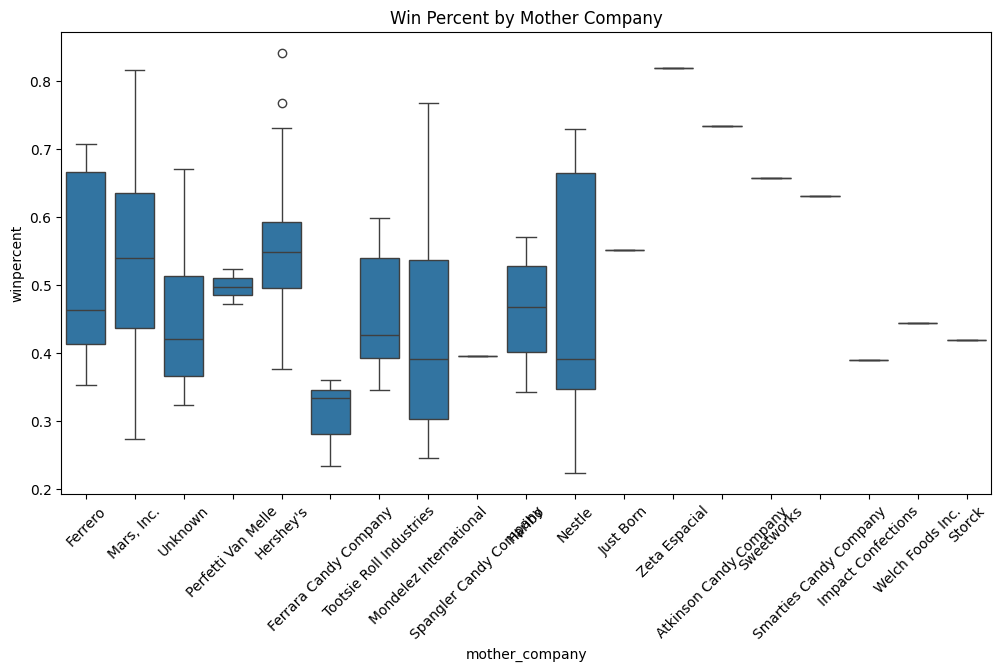

In [73]:
# plot box plots of winpercent by mother company
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(x='mother_company', y='winpercent', data=candy)
plt.xticks(rotation=45)
plt.title('Win Percent by Mother Company')
plt.show()



In [74]:
# test hypothesis that the mean winpercent is the same across all mother companies using ANOVA
import scipy.stats as stats
groups = [group['winpercent'].values for name, group in candy.groupby('mother_company')]
anova_result = stats.f_oneway(*groups)
print('ANOVA result:', anova_result)

ANOVA result: F_onewayResult(statistic=np.float64(1.538489155337097), pvalue=np.float64(0.10484610884115926))


In [78]:
# take top for mother companies by number of candy brands
top_companies = candy['mother_company'].value_counts().nlargest(4).index.tolist()
candy_top = candy[candy['mother_company'].isin(top_companies)]

In [81]:
import scipy.stats as stats
groups = [group['winpercent'].values for name, group in candy_top.groupby('mother_company')]
anova_result = stats.f_oneway(*groups)
print('ANOVA result:', anova_result)

ANOVA result: F_onewayResult(statistic=np.float64(1.2475214728582638), pvalue=np.float64(0.30295352432588013))


In [84]:
candy_top.mother_company

0                     Ferrero
1                  Mars, Inc.
5                   Hershey's
6                     Ferrero
9     Tootsie Roll Industries
10    Tootsie Roll Industries
13    Tootsie Roll Industries
15    Tootsie Roll Industries
16                    Ferrero
17                    Ferrero
22                  Hershey's
23                  Hershey's
24                  Hershey's
25                  Hershey's
27    Tootsie Roll Industries
28                  Hershey's
29                    Ferrero
31                 Mars, Inc.
32                 Mars, Inc.
33                    Ferrero
34                 Mars, Inc.
36                  Hershey's
37                 Mars, Inc.
38                 Mars, Inc.
39                 Mars, Inc.
40                  Hershey's
41                  Hershey's
42                    Ferrero
45    Tootsie Roll Industries
46                    Ferrero
47                    Ferrero
48                  Hershey's
49                    Ferrero
50        

In [82]:
candy.loc[candy['mother_company'] == "Hershey's", ['competitorname', 'mother_company']]

,competitorname,mother_company
5,Almond Joy,Hershey's
22,Hershey's Kisses,Hershey's
23,Hershey's Krackel,Hershey's
24,Hershey's Milk Chocolate,Hershey's
25,Hershey's Special Dark,Hershey's
28,Kit Kat,Hershey's
36,Milky Way,Hershey's
40,Mr Good Bar,Hershey's
41,Nerds,Hershey's
48,Pixie Sticks,Hershey's


In [86]:
candy.loc[candy['mother_company'] == "Mars, Inc.", ['competitorname', 'mother_company']]

,competitorname,mother_company
1,3 Musketeers,"Mars, Inc."
31,Lifesavers big ring gummies,"Mars, Inc."
32,Peanut butter M&M's,"Mars, Inc."
34,Mike & Ike,"Mars, Inc."
37,Milky Way Midnight,"Mars, Inc."
38,Milky Way Simply Caramel,"Mars, Inc."
39,Mounds,"Mars, Inc."
57,Root Beer Barrels,"Mars, Inc."
58,Runts,"Mars, Inc."
61,Skittles wildberry,"Mars, Inc."


In [93]:
# find out how much variance is in individual mother companies, most of the features are however categorical
import numpy as np
variance_by_company = candy.groupby('mother_company').agg(np.var)
variance_by_company

/var/folders/3r/pv_sqnpd6bb8wr1nhrml1snw0000gq/T/ipykernel_96827/80094293.py:3: FutureWarning: The provided callable <function var at 0x1085bc860> is currently using DataFrameGroupBy.var. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "var" instead.
  variance_by_company = candy.groupby('mother_company').agg(np.var)


TypeError: agg function failed [how->var,dtype->object]

### train catboost model and make it explainable

In [1]:
import pandas as pd
candy = pd.read_csv('/Users/A107809368/projects/playground/candy_case_study/data/candy-data-cleaned.csv')

In [2]:
candy.columns

Index(['competitorname', 'chocolate', 'fruity', 'caramel', 'peanutyalmondy',
       'nougat', 'crispedricewafer', 'hard', 'bar', 'pluribus', 'sugarpercent',
       'pricepercent', 'winpercent', 'mother_company'],
      dtype='object')

In [36]:
from catboost import Pool, cv

CAT_FEATURES = ['chocolate', 'fruity', 'caramel', 'peanutyalmondy', 'nougat',
                'crispedricewafer', 'hard', 'bar', 'pluribus', 'mother_company']

TO_DROP = ['competitorname']
X = candy.drop(columns=TO_DROP + ['winpercent'])
y = candy['winpercent']

# Create Pool object with categorical features
pool = Pool(data=X, label=y, cat_features=CAT_FEATURES)

# Parameters WITHOUT cat_features
params = {
    'iterations': 100,
    'learning_rate': 0.05,
    'depth': 6,
    'verbose': 100,
    'loss_function': 'RMSE',
}

# Run cross-validation with Pool object
cv_results = cv(
    pool=pool,
    params=params,
    fold_count=5,
    plot=True,
    return_models=True,
)

print(cv_results)

print(cv_results[1][4].get_feature_importance(prettified=True))

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training on fold [0/5]
0:	learn: 0.5134316	test: 0.4859746	best: 0.4859746 (0)	total: 3.1ms	remaining: 307ms
99:	learn: 0.0783757	test: 0.1021989	best: 0.1021989 (99)	total: 115ms	remaining: 0us

bestTest = 0.1021989194
bestIteration = 99

Training on fold [1/5]
0:	learn: 0.5005182	test: 0.5294422	best: 0.5294422 (0)	total: 1.11ms	remaining: 110ms
99:	learn: 0.0804680	test: 0.1273708	best: 0.1271671 (98)	total: 114ms	remaining: 0us

bestTest = 0.1271670691
bestIteration = 98

Training on fold [2/5]
0:	learn: 0.5175639	test: 0.4677789	best: 0.4677789 (0)	total: 1.71ms	remaining: 169ms
99:	learn: 0.0706621	test: 0.1104110	best: 0.1103042 (96)	total: 139ms	remaining: 0us

bestTest = 0.1103042166
bestIteration = 96

Training on fold [3/5]
0:	learn: 0.5036114	test: 0.5187610	best: 0.5187610 (0)	total: 3.38ms	remaining: 334ms
99:	learn: 0.0750454	test: 0.1367565	best: 0.1367565 (99)	total: 189ms	remaining: 0us

bestTest = 0.1367565222
bestIteration = 99

Training on fold [4/5]
0:	learn: 0.49

In [41]:
cv_results[1][4].get_feature_importance(prettified=True)

,Feature Id,Importances
0,pricepercent,25.658493
1,chocolate,22.989018
2,sugarpercent,17.233677
3,pluribus,10.714066
4,fruity,6.591177
5,hard,6.375913
6,peanutyalmondy,2.716902
7,bar,2.539804
8,mother_company,1.808174
9,caramel,1.606896


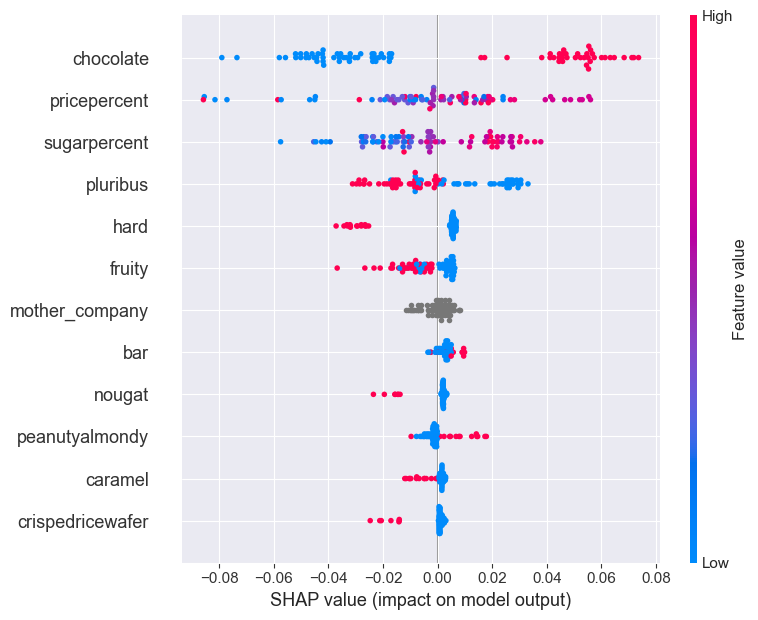

In [40]:
# get shapley values
import shap
explainer = shap.Explainer(cv_results[1][4])
shap_values = explainer(X)
# plot shapley values
shap.summary_plot(shap_values, X)



In [14]:
# show summary of cv results
print(cv_results.describe())
# get feature importances from cv_results


       iterations  test-RMSE-mean  test-RMSE-std  train-RMSE-mean  \
count  100.000000      100.000000     100.000000       100.000000   
mean    49.500000        0.200183       0.023245         0.175067   
std     29.011492        0.100535       0.004975         0.112639   
min      0.000000        0.123034       0.016080         0.074268   
25%     24.750000        0.128960       0.019013         0.092288   
50%     49.500000        0.151524       0.023559         0.125726   
75%     74.250000        0.237686       0.027897         0.223206   
max     99.000000        0.507596       0.031391         0.506959   

       train-RMSE-std  
count      100.000000  
mean         0.005536  
std          0.001069  
min          0.003789  
25%          0.004662  
50%          0.005445  
75%          0.006202  
max          0.008065  


In [15]:
importances

Series([], dtype: float64)

In [42]:
candy

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent,mother_company
0,100 Grand,1,0,1,0,0,1,0,1,0,0.901261,0.860,0.670,Ferrero
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.445922,0.511,0.676,"Mars, Inc."
2,One dime,0,0,0,0,0,0,0,0,0,-1.663576,0.116,0.323,Unknown
3,One quarter,0,0,0,0,0,0,0,0,0,-1.663576,0.511,0.461,Unknown
4,Air Heads,0,1,0,0,0,0,0,0,0,1.520236,0.511,0.523,Perfetti Van Melle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,Twizzlers,0,1,0,0,0,0,0,0,0,-0.920093,0.116,0.455,Hershey's
81,Warheads,0,1,0,0,0,0,1,0,0,-1.371875,0.116,0.390,Impact Confections
82,Welch's Fruit Snacks,0,1,0,0,0,0,0,0,1,-0.589262,0.313,0.444,Welch Foods Inc.
83,Werther's Original Caramel,0,0,1,0,0,0,1,0,0,-1.041043,0.267,0.419,Storck
